# ЛР 04 — ноутбук 2 (solution): выбор порога и правила решения

## Как работать с этим ноутбуком
- Это полный разбор выбора правила решения с учетом цены ошибок.
- Строго соблюдаем контракт по данным: выбираем на `validation`, проверяем один раз на `test`.
- На каждом шаге фиксируем мини-вывод, чтобы не потерять логику решения.


In [1]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Подключаем зависимости для этого шага.
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Строим визуализацию и проверяем интерпретируемость результата.
sns.set_theme(style='whitegrid', context='notebook')

# Итерируемся по объектам и последовательно накапливаем результаты.
for candidate in [Path.cwd(), Path.cwd().parent]:
    if str(candidate) not in sys.path:
        sys.path.append(str(candidate))

LAB_DIR = next(
    (candidate for candidate in [Path.cwd(), Path.cwd().parent] if (candidate / 'lab_utils.py').exists()),
    Path.cwd(),
)
OUTPUT_DIR = LAB_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Подключаем зависимости для этого шага.
import lab_utils as lab

np.random.seed(lab.SEED)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


## Шаг 1. Подготовка контекста для выбора правила решения

### Что делаем
- Загружаем `calibration_audit.csv`.
- Определяем `calibrated_best_source` для каждого набора данных.

### Зачем
Чтобы сократить набор кандидатов до пары `uncalibrated` и `calibrated_best`.

### Вход
`outputs/calibration_audit.csv`, гипотезы ЛР 03.

### Выход
`variant_summary`.

### Проверь себя
- В `calibration_audit` только проверочная выборка `validation`?
- Для каждого набора данных найден `calibrated_best`?

### Мини-вывод
Коротко зафиксируйте, почему выбранный набор кандидатов корректен.

Переход к следующему шагу: кандидаты определены, можно строить сетку порогов.


In [2]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Читаем данные и артефакты, с которыми будем работать дальше.
calibration_audit = pd.read_csv(OUTPUT_DIR / 'calibration_audit.csv')
datasets = lab.load_course_datasets()
feature_sets = lab.load_feature_sets_raw()
hypotheses = lab.load_lab03_hypotheses()

# Проверяем обязательное условие корректности шага.
assert set(calibration_audit['split'].unique()) == {'validation'}, 'Ожидаем только проверочную выборку `validation`.'

variant_summary_rows = []
# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name in sorted(lab.DATASET_PATHS):
    best_source_variant = lab.choose_best_calibrated_variant(calibration_audit, dataset_name)
    variant_summary_rows.append(
        {
            'dataset': dataset_name,
            'use_variants': 'uncalibrated + calibrated_best',
            'calibrated_best_source': best_source_variant,
        }
    )

variant_summary = pd.DataFrame(variant_summary_rows)
variant_summary


,dataset,use_variants,calibrated_best_source
0,finance,uncalibrated + calibrated_best,calibrated_sigmoid
1,medical,uncalibrated + calibrated_best,calibrated_isotonic


### Мини-вывод (пример)
Входной аудит калибровки корректен: для каждого набора данных определен `calibrated_best`.
Теперь можно переходить к перебору порогов без обращения к тестовой выборке.

Переход к следующему шагу: кандидаты определены, можно строить сетку порогов.


## Шаг 2. Перебор порога на проверочной выборке `validation` + графики

### Что делаем
- Обучаем двух кандидатов: `uncalibrated` и `calibrated_best`.
- Для каждого кандидата строим таблицу порогов на `validation`.
- Выбираем кандидата правила решения с учетом ограничения-страховки.

### Зачем
Это центральный шаг: минимизируем стоимость ошибок, но не допускаем опасного падения полноты.

### Вход
`variant_summary`, данные и конвейер подготовки.

### Выход
`threshold_policy_grid`, `selected_policies`, графики `порог -> метрика`.

### Проверь себя
- Все пороги в диапазоне [0, 1]?
- Для каждого набора данных сравниваются ровно два варианта?

### Теория шага (интуиция + формулы)

- правило: $\hat{y}=1$, если $p\ge t$, иначе $0$;
- стоимость ошибок:
  
  $\text{Cost}_{total} = FP\_cost\cdot FP + FN\_cost\cdot FN$;
  
  $\text{ExpectedCost} = \frac{\text{Cost}_{total}}{N}$;
- Ограничение-страховка (guardrail) по `recall` защищает от «дешевого, но опасного» порога.

### Мини-вывод
Опишите, какой диапазон порогов оказался разумным и почему.

Переход к следующему шагу: из таблицы порогов выбираем финальное правило на каждый набор данных.


In [3]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

# Мини-пример: как считается ожидаемая стоимость ошибок (expected cost)
mini_y = np.array([1, 1, 0, 0, 1, 0], dtype=int)
mini_p = np.array([0.9, 0.7, 0.8, 0.3, 0.45, 0.2], dtype=float)
mini_t = 0.5
mini_pred = (mini_p >= mini_t).astype(int)
mini_cost = lab.compute_expected_cost(mini_y, mini_pred, fp_cost=lab.DEFAULT_FP_COST, fn_cost=lab.DEFAULT_FN_COST)

pd.DataFrame({'threshold': [mini_t], 'pred': [mini_pred.tolist()], 'expected_cost': [mini_cost]})


,threshold,pred,expected_cost
0,0.5,"[1, 1, 1, 0, 0, 0]",1.0


In [4]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

threshold_rows = []
selected_policy_rows = []
trained_context = {}

# Итерируемся по объектам и последовательно накапливаем результаты.
for row in hypotheses.itertuples(index=False):
    dataset_name = row.dataset
    model_name = row.model
    feature_set_name = row.feature_set

    # Восстанавливаем разбиение train/validation/test и нужные признаки
    df = datasets[dataset_name]
    x, y = lab.split_xy(df)
    x_train, x_valid, x_test, y_train, y_valid, y_test = lab.train_valid_test_split_stratified(x, y)

    selected_features = lab.get_feature_set_features(feature_sets, dataset_name, feature_set_name)
    x_train_s, x_valid_s, x_test_s, _ = lab.prepare_selected_matrices(
        x_train=x_train,
        x_valid=x_valid,
        x_test=x_test,
        selected_features=selected_features,
    )

    variants_raw = lab.train_model_variants(model_name=model_name, x_train=x_train_s, y_train=y_train)
    calibrated_best_source = lab.choose_best_calibrated_variant(calibration_audit, dataset_name)

    variant_models = {
        'uncalibrated': variants_raw['uncalibrated'],
        'calibrated_best': variants_raw[calibrated_best_source],
    }

    trained_context[dataset_name] = {
        'model_name': model_name,
        'x_test_raw': x_test.reset_index(drop=True),
        'x_test_selected': x_test_s,
        'y_test': y_test.reset_index(drop=True),
        'variant_models': variant_models,
    }

    # Итерируемся по объектам и последовательно накапливаем результаты.
    for variant_label, model in variant_models.items():
        valid_scores = lab.get_binary_score_vector(model, x_valid_s)
        grid = lab.sweep_thresholds(
            y_true=y_valid,
            y_score=valid_scores,
            fp_cost=lab.DEFAULT_FP_COST,
            fn_cost=lab.DEFAULT_FN_COST,
        )
        grid['dataset'] = dataset_name
        grid['model'] = model_name
        grid['variant'] = variant_label
        grid = grid.loc[:, lab.THRESHOLD_POLICY_GRID_COLUMNS]
        threshold_rows.append(grid)

        winner = lab.choose_threshold_policy(grid, min_recall=lab.DEFAULT_MIN_RECALL)
        selected_policy_rows.append(
            {
                'dataset': dataset_name,
                'model': model_name,
                'variant': variant_label,
                'policy_name': str(winner['policy_name']),
                'threshold': float(winner['threshold']),
                'validation_expected_cost': float(winner['expected_cost']),
                'guardrail_passed': bool(winner['guardrail_passed']),
                'validation_f1': float(winner['f1']),
                'validation_recall': float(winner['recall']),
            }
        )

threshold_policy_grid = pd.concat(threshold_rows, ignore_index=True)
selected_policies = pd.DataFrame(selected_policy_rows)
threshold_policy_grid.head(10)


,dataset,model,variant,threshold,precision,recall,f1,fp_rate,fn_rate,expected_cost
0,finance,LogisticRegression,uncalibrated,0.05,0.372727,1.000000,0.543046,0.627273,0.000000,0.627273
1,finance,LogisticRegression,uncalibrated,0.10,0.372727,1.000000,0.543046,0.627273,0.000000,0.627273
2,finance,LogisticRegression,uncalibrated,0.15,0.372727,1.000000,0.543046,0.627273,0.000000,0.627273
3,finance,LogisticRegression,uncalibrated,0.20,0.382075,0.987805,0.551020,0.595455,0.004545,0.618182
4,finance,LogisticRegression,uncalibrated,0.25,0.391089,0.963415,0.556338,0.559091,0.013636,0.627273
5,finance,LogisticRegression,uncalibrated,0.30,0.413978,0.939024,0.574627,0.495455,0.022727,0.609091
6,finance,LogisticRegression,uncalibrated,0.35,0.426036,0.878049,0.573705,0.440909,0.045455,0.668182
7,finance,LogisticRegression,uncalibrated,0.40,0.476190,0.853659,0.611354,0.350000,0.054545,0.622727
8,finance,LogisticRegression,uncalibrated,0.45,0.488000,0.743902,0.589372,0.290909,0.095455,0.768182
9,finance,LogisticRegression,uncalibrated,0.50,0.518182,0.695122,0.593750,0.240909,0.113636,0.809091


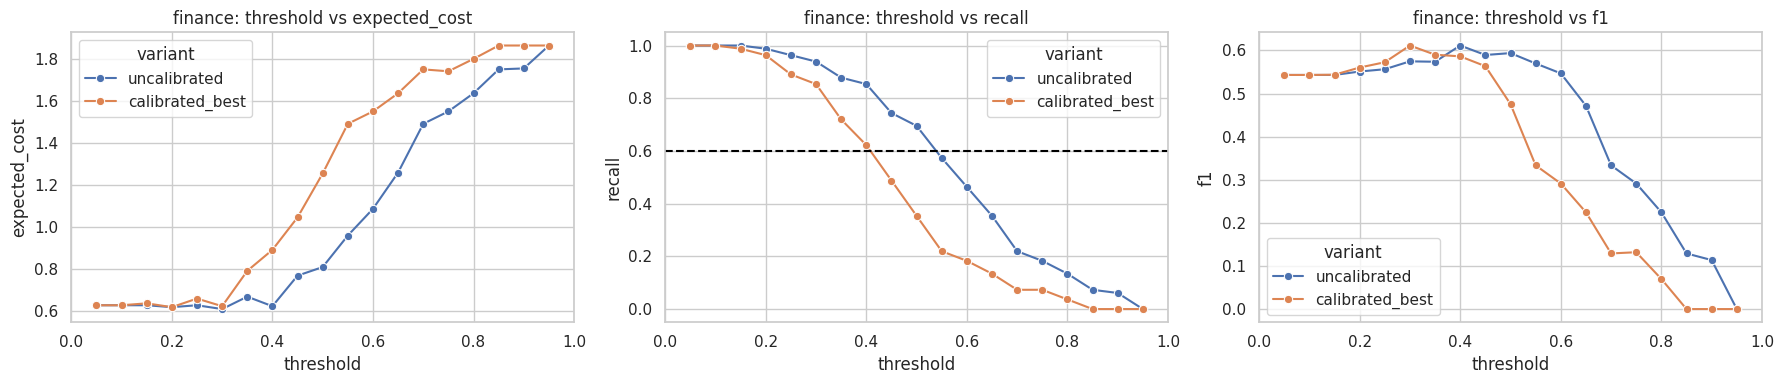

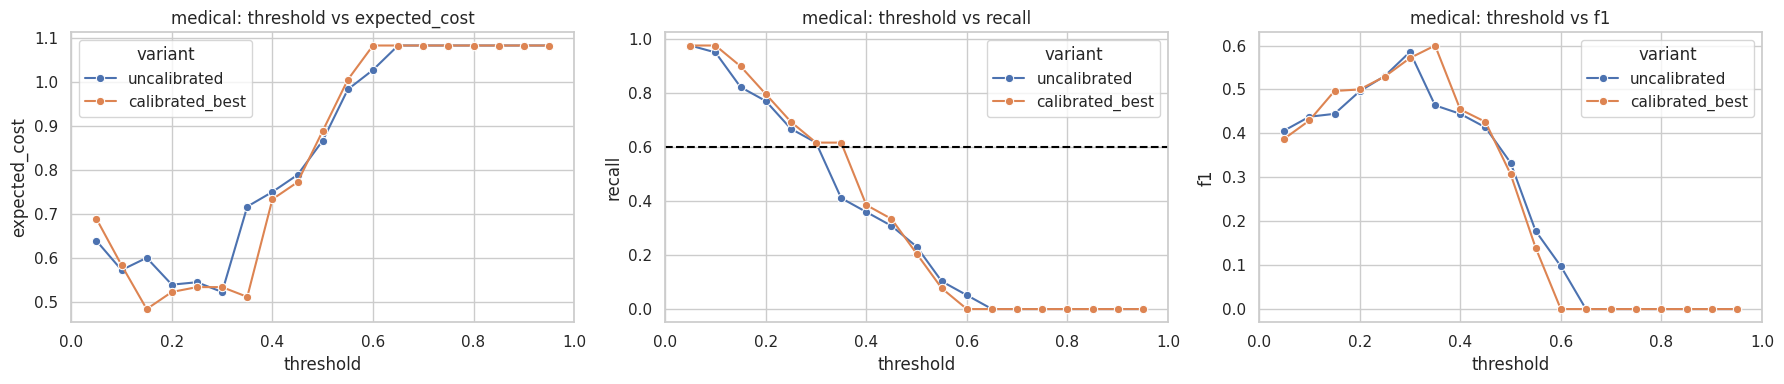

In [5]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

# Обязательная визуализация: порог -> expected_cost / recall / f1
# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name in sorted(threshold_policy_grid['dataset'].unique()):
    ds = threshold_policy_grid[threshold_policy_grid['dataset'] == dataset_name].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
    # Строим визуализацию и проверяем интерпретируемость результата.
    sns.lineplot(data=ds, x='threshold', y='expected_cost', hue='variant', marker='o', ax=axes[0])
    axes[0].set_title(f'{dataset_name}: threshold vs expected_cost')

    # Строим визуализацию и проверяем интерпретируемость результата.
    sns.lineplot(data=ds, x='threshold', y='recall', hue='variant', marker='o', ax=axes[1])
    axes[1].axhline(lab.DEFAULT_MIN_RECALL, linestyle='--', color='black', label='min_recall')
    axes[1].set_title(f'{dataset_name}: threshold vs recall')

    # Строим визуализацию и проверяем интерпретируемость результата.
    sns.lineplot(data=ds, x='threshold', y='f1', hue='variant', marker='o', ax=axes[2])
    axes[2].set_title(f'{dataset_name}: threshold vs f1')

    # Итерируемся по объектам и последовательно накапливаем результаты.
    for ax in axes:
        ax.set_xlim(0, 1)

    # Строим визуализацию и проверяем интерпретируемость результата.
    plt.tight_layout()
    plt.show()


### Мини-вывод (пример)
Графики показывают понятный компромисс: при росте порога обычно падает `recall`, а стоимость может как снижаться, так и расти.
Ограничение по `recall` отсеивает пороги, которые формально дешевле, но слишком рискованны.

Переход к следующему шагу: из таблицы порогов выбираем финальное правило на каждый набор данных.


## Шаг 3. Выбор финального правила решения по проверочной выборке `validation`

### Что делаем
Выбираем по одному финальному кандидату правила решения на каждый набор данных.

### Зачем
Чтобы один раз проверить уже принятое решение на тестовой выборке `test`.

### Вход
`selected_policies`.

### Выход
`final_policy_selection` и график сравнения.

### Проверь себя
- По одному кандидату для каждого набора данных?
- Выбор сделан без использования `test`?

### Мини-вывод
Сформулируйте, почему выбранный кандидат лучше альтернатив.

Переход к следующему шагу: финальные правила зафиксированы, выполняем итоговую проверку на `test`.


In [6]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

final_policy_selection = (
    selected_policies
    .sort_values(['dataset', 'validation_expected_cost', 'validation_f1'], ascending=[True, True, False])
    .drop_duplicates(['dataset'], keep='first')
    .reset_index(drop=True)
)

final_policy_selection


,dataset,model,variant,policy_name,threshold,validation_expected_cost,guardrail_passed,validation_f1,validation_recall
0,finance,LogisticRegression,uncalibrated,min_cost_recall_ge_0.60,0.30,0.609091,True,0.574627,0.939024
1,medical,RandomForest,calibrated_best,min_cost_recall_ge_0.60,0.15,0.483333,True,0.496454,0.897436


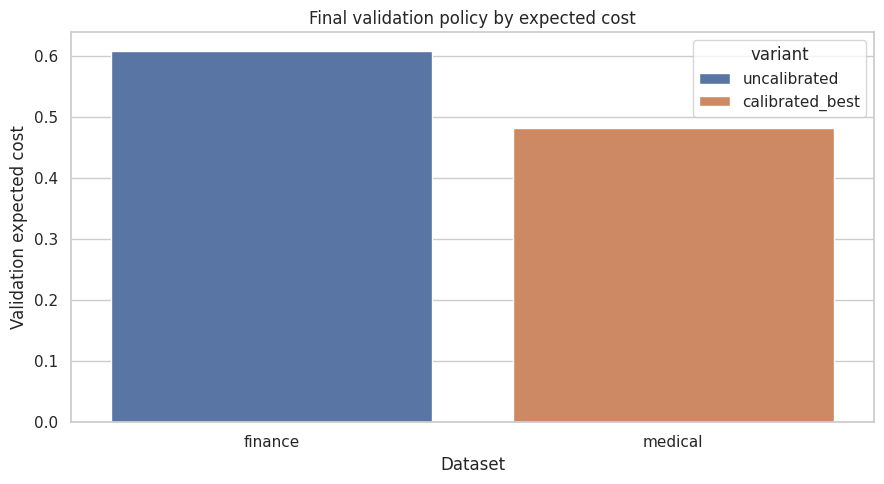

In [7]:
# Что делаем: Строим графики для визуальной проверки гипотез и выводов.
# Зачем: Графики помогают увидеть закономерности, которые неочевидны по одной таблице метрик.
# Как читать результат: Сопоставьте форму графика с числовыми метриками: они должны подтверждать друг друга.
# Типичные ошибки: Частая ошибка — делать вывод только по картинке без проверки числовых значений.

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(9, 5))
sns.barplot(data=final_policy_selection, x='dataset', y='validation_expected_cost', hue='variant')
plt.title('Final validation policy by expected cost')
plt.ylabel('Validation expected cost')
plt.xlabel('Dataset')
plt.tight_layout()
plt.show()


### Мини-вывод (пример)
Финальный кандидат выбран на `validation` по ожидаемой стоимости и ограничению по `recall`.
После этого параметры не подстраиваются: мы идем в единственную честную проверку на `test`.

Переход к следующему шагу: финальные правила зафиксированы, выполняем итоговую проверку на `test`.


## Шаг 4. Одна финальная проверка на тестовой выборке `test` выбранного правила решения

### Что делаем
- Применяем только выбранные правила решения к `test`.
- Формируем `policy_test_report` и `segment_policy_audit`.
- Строим график сегментной стоимости.

### Зачем
Это финальная и честная оценка уже принятого решения.

### Вход
`final_policy_selection`, `trained_context`.

### Выход
`policy_test_report`, `segment_policy_audit`, график.

### Проверь себя
- В `policy_test_report` по одной строке для каждого набора данных?
- После просмотра `test` порог больше не меняется?

### Мини-вывод
Опишите, где решение сработало стабильно, а где видны риски.

Переход к следующему шагу: проверка завершена, можно сохранять финальные артефакты.


In [8]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

policy_test_rows = []
segment_frames = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for row in final_policy_selection.itertuples(index=False):
    dataset_name = row.dataset
    variant_name = row.variant
    threshold = float(row.threshold)

    ctx = trained_context[dataset_name]
    model = ctx['variant_models'][variant_name]

    test_scores = lab.get_binary_score_vector(model, ctx['x_test_selected'])
    test_metrics = lab.evaluate_policy_on_split(
        y_true=ctx['y_test'],
        y_score=test_scores,
        threshold=threshold,
        fp_cost=lab.DEFAULT_FP_COST,
        fn_cost=lab.DEFAULT_FN_COST,
    )

    policy_test_rows.append(
        {
            'dataset': dataset_name,
            'model': ctx['model_name'],
            'variant': variant_name,
            'policy_name': row.policy_name,
            'threshold': threshold,
            **test_metrics,
        }
    )

    y_pred = (test_scores >= threshold).astype(int)
    segment_feature = lab.SEGMENT_FEATURES[dataset_name][0]
    segment_values = ctx['x_test_raw'][segment_feature]
    segment_df = lab.build_segment_policy_audit(
        dataset_name=dataset_name,
        segment_feature=segment_feature,
        segment_values=segment_values,
        y_true=ctx['y_test'],
        y_pred=y_pred,
        fp_cost=lab.DEFAULT_FP_COST,
        fn_cost=lab.DEFAULT_FN_COST,
        n_bins=4,
    )
    segment_frames.append(segment_df)

policy_test_report = pd.DataFrame(policy_test_rows).loc[:, lab.POLICY_TEST_REPORT_COLUMNS]
segment_policy_audit = pd.concat(segment_frames, ignore_index=True).loc[:, lab.SEGMENT_POLICY_AUDIT_COLUMNS]

policy_test_report


,dataset,model,variant,policy_name,threshold,accuracy,f1,roc_auc,pr_auc,expected_cost,cost_per_100
0,finance,LogisticRegression,uncalibrated,min_cost_recall_ge_0.60,0.30,0.454545,0.562044,0.692294,0.637960,0.636364,63.636364
1,medical,RandomForest,calibrated_best,min_cost_recall_ge_0.60,0.15,0.577778,0.457143,0.707401,0.391014,0.577778,57.777778


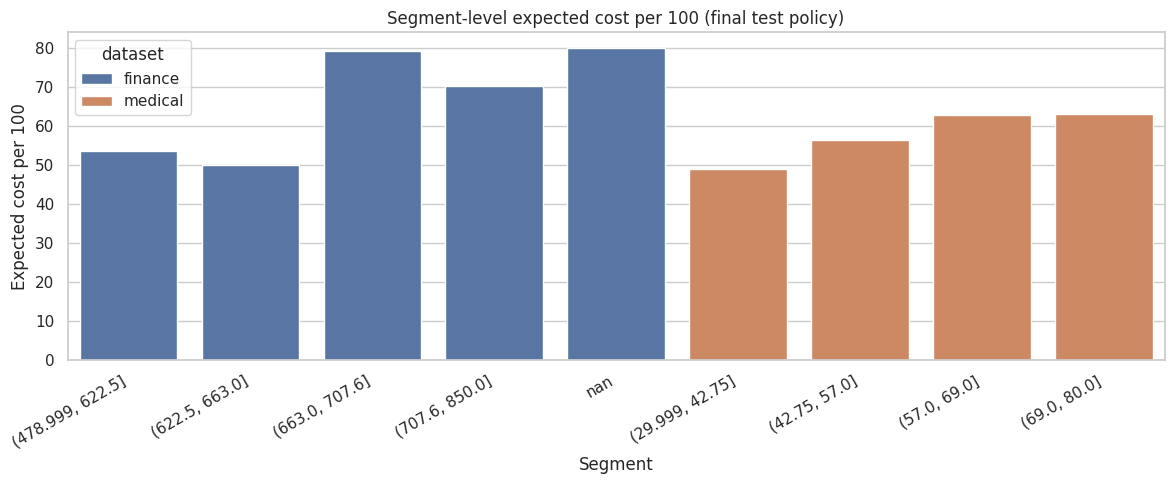

,dataset,segment_feature,segment,n,fp_rate,fn_rate,expected_cost_per_100
0,finance,credit_score,"(478.999, 622.5]",54,0.537037,0.000000,53.703704
1,finance,credit_score,"(622.5, 663.0]",54,0.500000,0.000000,50.000000
2,finance,credit_score,"(663.0, 707.6]",53,0.509434,0.056604,79.245283
3,finance,credit_score,"(707.6, 850.0]",54,0.518519,0.037037,70.370370
4,finance,credit_score,nan,5,0.800000,0.000000,80.000000
5,medical,age,"(29.999, 42.75]",45,0.155556,0.066667,48.888889
6,medical,age,"(42.75, 57.0]",46,0.347826,0.043478,56.521739
7,medical,age,"(57.0, 69.0]",51,0.529412,0.019608,62.745098
8,medical,age,"(69.0, 80.0]",38,0.500000,0.026316,63.157895


In [9]:
# Что делаем: Строим графики для визуальной проверки гипотез и выводов.
# Зачем: Графики помогают увидеть закономерности, которые неочевидны по одной таблице метрик.
# Как читать результат: Сопоставьте форму графика с числовыми метриками: они должны подтверждать друг друга.
# Типичные ошибки: Частая ошибка — делать вывод только по картинке без проверки числовых значений.

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(12, 5))
sns.barplot(data=segment_policy_audit, x='segment', y='expected_cost_per_100', hue='dataset')
plt.title('Ожидаемая стоимость на 100 наблюдений по сегментам (финальная проверка на test)')
plt.xlabel('Segment')
plt.ylabel('Expected cost per 100')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

segment_policy_audit.head(10)


### Мини-вывод (пример)
Финальное правило проверено один раз и дополнительно разобрано по сегментам.
Так мы видим не только среднюю метрику, но и зоны повышенного риска.

Переход к следующему шагу: проверка завершена, можно сохранять финальные артефакты.


## Шаг 5. Экспорт обязательных артефактов

### Что делаем
Сохраняем `threshold_policy_grid.csv`, `policy_test_report.csv`, `segment_policy_audit.csv`.

### Зачем
Это публичные артефакты ЛР 04 для отчета и внутренней проверки.

### Вход
Три итоговых DataFrame.

### Выход
Три CSV в `outputs/`.

### Проверь себя
- Колонки соответствуют контракту?
- Число строк и наборов данных соответствует ожиданиям?

### Мини-вывод
Подтвердите, что артефакты сохранены и готовы для отчета.

Переход к следующему шагу: ноутбук завершен, переходим к отчету и итоговым рекомендациям.


In [10]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

threshold_path = OUTPUT_DIR / 'threshold_policy_grid.csv'
policy_path = OUTPUT_DIR / 'policy_test_report.csv'
segment_path = OUTPUT_DIR / 'segment_policy_audit.csv'

# Сохраняем таблицу артефакта в CSV.
threshold_policy_grid.to_csv(threshold_path, index=False)
policy_test_report.to_csv(policy_path, index=False)
segment_policy_audit.to_csv(segment_path, index=False)

print(f'Saved: {threshold_path.resolve()} | rows={len(threshold_policy_grid)}')
print(f'Saved: {policy_path.resolve()} | rows={len(policy_test_report)}')
print(f'Saved: {segment_path.resolve()} | rows={len(segment_policy_audit)}')


Saved: /home/sorcerer/Projects/edu-big-data-machine-models/04-calibration-threshold-and-decision-policy/outputs/threshold_policy_grid.csv | rows=76
Saved: /home/sorcerer/Projects/edu-big-data-machine-models/04-calibration-threshold-and-decision-policy/outputs/policy_test_report.csv | rows=2
Saved: /home/sorcerer/Projects/edu-big-data-machine-models/04-calibration-threshold-and-decision-policy/outputs/segment_policy_audit.csv | rows=9
